In [1]:
from doctest import debug, debug_script
from hashlib import algorithms_available
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from skimage.restoration import unwrap_phase

# Point sys.path to the repository root
repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

# Import the PhaseMapGenerator (assuming you saved it in src/phase_map_generator.py)
# from src.phase_map_generator import PhaseMapGenerator
import config
import src.phase_extraction as pe
import src.calibration as calib
import src.slit_analysis as sa

C:\Users\vmlab\Documents\eb4t_code\nozzle_analysis\src\reading_hdf5.py:6: UserWarning: The numpy.array_api submodule is still experimental. See NEP 47.
  from numpy.array_api import uint8


# Phase extraction at 90 degrees

Unsupported data type for _convert.
Unsupported data type for _convert.


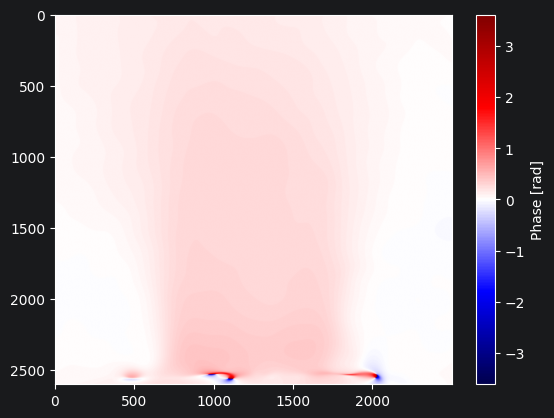

In [17]:
hdf5_path = r"C:\Users\vmlab\Documents\data\files\2026\09\23\nozzle_155\Ar_5_bar\90_deg"

roi = [2000, 4800, 1000, 3700]  # [x_start, x_end, y_start, y_end]
ref_img, exp_img, ref_roi, exp_roi = pe.get_interferometry_images(hdf5_path, roi=roi)

ref_fourier_shifted = pe.get_fourier(ref_roi)
exp_fourier_shifted = pe.get_fourier(exp_roi)

dominant_frequency = pe.get_dominant_frequency(ref_fourier_shifted, debug=False)

delta_phase_wrapped = pe.get_delta_phase_wrapped(ref_fourier_shifted, exp_fourier_shifted, dominant_frequency,
                                                 debug=False)
ref_edge, *_ = calib.estimate_nozzle_edge(ref_roi)
x_left, x_right = calib.detect_nozzle_x_range(ref_roi, ref_edge)
x_left += 50
x_right -= 50
calibrated_phase_perp, _ = calib.calibrate_phase(delta_phase_wrapped, ref_edge, x_left, x_right, debug=True)

# Constants
NOZZLE_WIDTH_MM = 8.0
NOZZLE_OPENING_MM = 0.5
px_to_mm = calib.calculate_px_to_mm(x_left, x_right, NOZZLE_WIDTH_MM)


# Phase extraction at 0 degrees

Unsupported data type for _convert.
Unsupported data type for _convert.


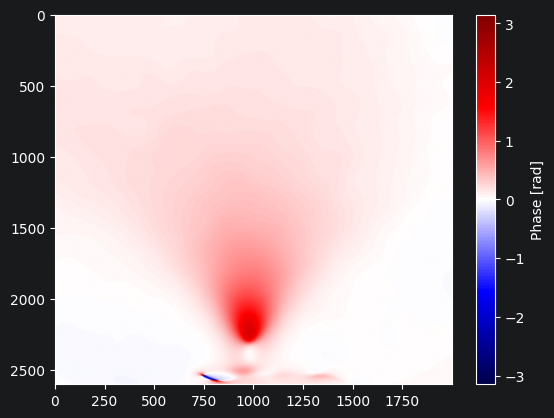

In [18]:

hdf5_path = r"C:\Users\vmlab\Documents\data\files\2026\09\23\nozzle_155\Ar_5_bar\0_deg"

roi = [2000, 4800, 1200, 3400]  # [x_start, x_end, y_start, y_end]
ref_img, exp_img, ref_roi, exp_roi = pe.get_interferometry_images(hdf5_path, roi=roi)

ref_fourier_shifted = pe.get_fourier(ref_roi)
exp_fourier_shifted = pe.get_fourier(exp_roi)

dominant_frequency = pe.get_dominant_frequency(ref_fourier_shifted, debug = False)

delta_phase_wrapped = pe.get_delta_phase_wrapped(ref_fourier_shifted, exp_fourier_shifted, dominant_frequency, debug = False)
ref_edge, *_ = calib.estimate_nozzle_edge(ref_roi)
x_left, x_right = calib.detect_nozzle_x_range(ref_roi, ref_edge)
calibrated_phase_para, _ = calib.calibrate_phase(delta_phase_wrapped, ref_edge, x_left, x_right, debug = True)


# density calculation

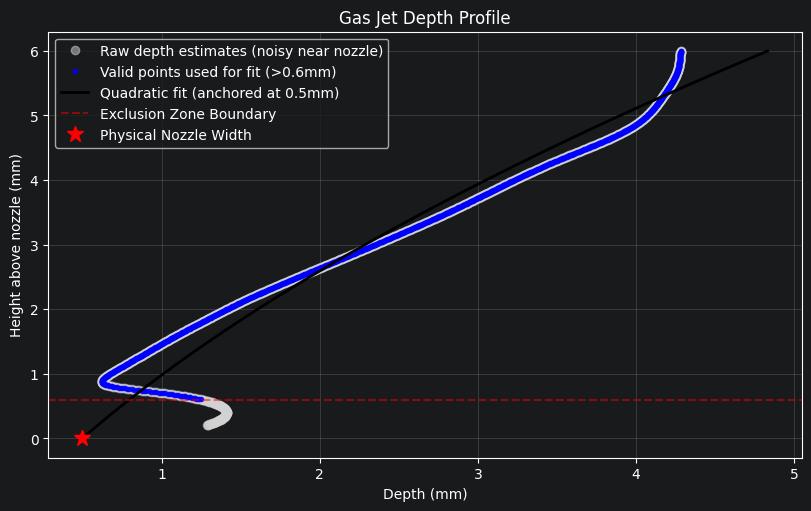

In [19]:
# Crop to 6mm and Flip (so y=0 is the nozzle edge)
phi_cropped = sa.crop_and_format_phase_map(
    calibrated_phase_para,
    nozzle_edge_y=ref_edge,
    px_to_mm=px_to_mm,
    max_height_mm=6.0
)

# Calculate Depth
y_mm_para, depth_fit_para, depth_debug = sa.estimate_depth_profile(
    phi_cropped,
    px_to_mm,
    nozzle_opening=NOZZLE_OPENING_MM,
    fit_type="quadratic_constrained",
    exclude_y_mm=0.6,
    debug_show=True,

)

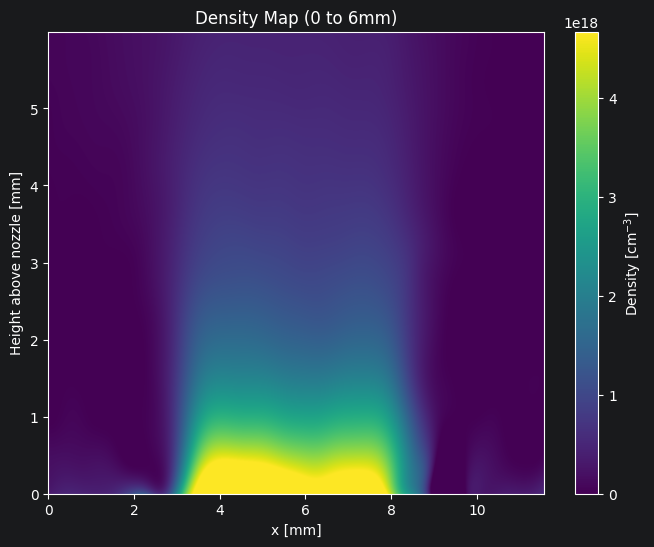

In [20]:
# Convert to Density
calibrated_phase_perp = sa.crop_and_format_phase_map(
    calibrated_phase_perp,
    nozzle_edge_y=ref_edge,
    px_to_mm=px_to_mm,
    max_height_mm=6.0)
density_map, x_mm, y_mm = sa.phase_to_density(calibrated_phase_perp, px_to_mm, depth_y_mm=y_mm_para, depth_profile_mm=depth_fit_para, gas="argon")

# Plot the result
plt.figure(figsize=(8, 6))
m = np.nanpercentile(np.abs(density_map), 98.0)
extent = [x_mm[0], x_mm[-1], y_mm[0], y_mm[-1]]
plt.imshow(density_map, origin="lower", extent=extent, aspect="auto", cmap="viridis", vmin=0.0, vmax=m)
plt.title("Density Map (0 to 6mm)")
plt.xlabel("x [mm]")
plt.ylabel("Height above nozzle [mm]")
plt.colorbar(label="Density [cm$^{-3}$]")
plt.show()

# 6 Bar Analysis

Unsupported data type for _convert.
Unsupported data type for _convert.
Unsupported data type for _convert.
Unsupported data type for _convert.


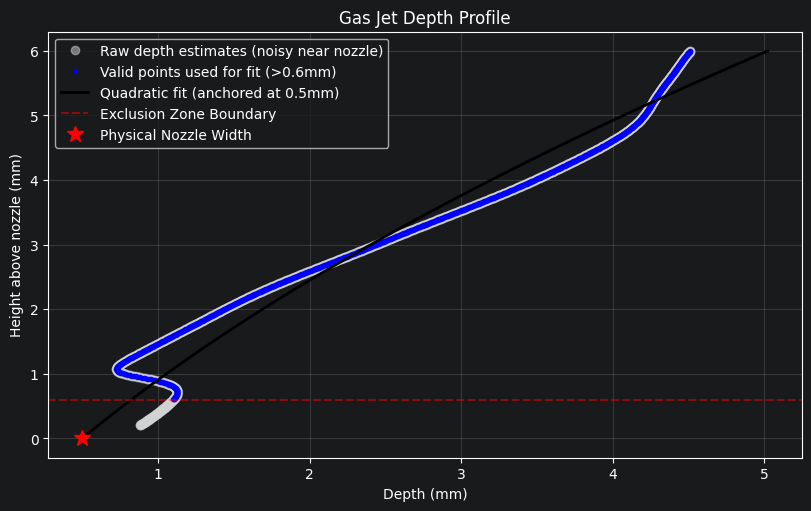

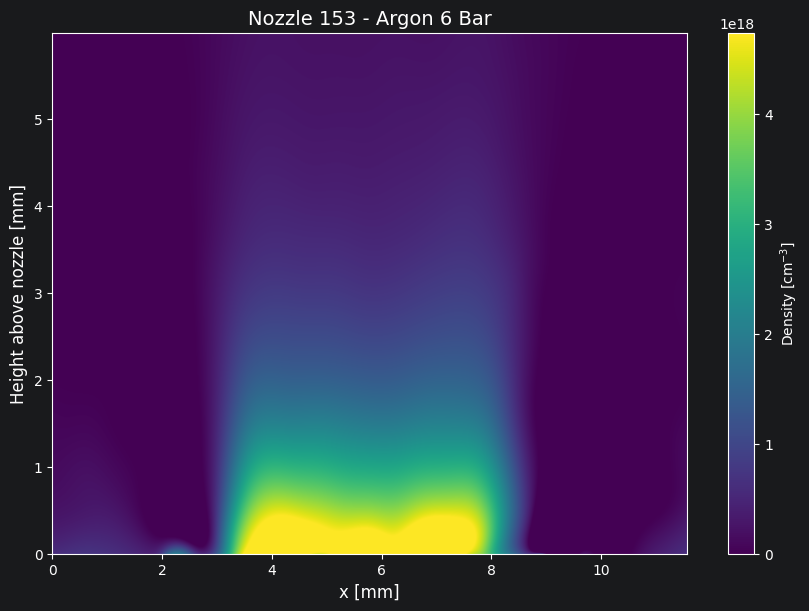

In [21]:
# ==========================================
# 6 BAR ANALYSIS
# ==========================================
# Paths for 6 bar
hdf5_path_90 = r"C:\Users\vmlab\Documents\data\files\2026\09\23\nozzle_155\Ar_6_bar\90_deg"
hdf5_path_0  = r"C:\Users\vmlab\Documents\data\files\2026\09\23\nozzle_155\Ar_6_bar\0_deg"

roi_90 = [2000, 4800, 1000, 3700]
roi_0  = [2000, 4800, 1200, 3400]

# --- 1. Process 90-degree (Perpendicular) ---
ref_img_90, exp_img_90, ref_roi_90, exp_roi_90 = pe.get_interferometry_images(hdf5_path_90, roi=roi_90)
ref_fourier_90 = pe.get_fourier(ref_roi_90)
exp_fourier_90 = pe.get_fourier(exp_roi_90)
dom_freq_90 = pe.get_dominant_frequency(ref_fourier_90, debug=False)
delta_phase_90 = pe.get_delta_phase_wrapped(ref_fourier_90, exp_fourier_90, dom_freq_90, debug=False)
ref_edge_90, *_ = calib.estimate_nozzle_edge(ref_roi_90)
x_left_90, x_right_90 = calib.detect_nozzle_x_range(ref_roi_90, ref_edge_90)
calibrated_phase_perp, _ = calib.calibrate_phase(delta_phase_90, ref_edge_90, x_left_90, x_right_90, debug=False)

# --- 2. Process 0-degree (Parallel) ---
ref_img_0, exp_img_0, ref_roi_0, exp_roi_0 = pe.get_interferometry_images(hdf5_path_0, roi=roi_0)
ref_fourier_0 = pe.get_fourier(ref_roi_0)
exp_fourier_0 = pe.get_fourier(exp_roi_0)
dom_freq_0 = pe.get_dominant_frequency(ref_fourier_0, debug=False)
delta_phase_0 = pe.get_delta_phase_wrapped(ref_fourier_0, exp_fourier_0, dom_freq_0, debug=False)
ref_edge_0, *_ = calib.estimate_nozzle_edge(ref_roi_0)
x_left_0, x_right_0 = calib.detect_nozzle_x_range(ref_roi_0, ref_edge_0)
calibrated_phase_para, _ = calib.calibrate_phase(delta_phase_0, ref_edge_0, x_left_0, x_right_0, debug=False)

# --- 3. Crop and Compute Depth (from 0-deg) ---
phi_cropped_para = sa.crop_and_format_phase_map(
    calibrated_phase_para, nozzle_edge_y=ref_edge_0, px_to_mm=px_to_mm, max_height_mm=6.0
)
y_mm_para, depth_fit_para, depth_debug = sa.estimate_depth_profile(
    phi_cropped_para, px_to_mm, nozzle_opening=NOZZLE_OPENING_MM, fit_type="quadratic_constrained", exclude_y_mm=0.6, debug_show=True
)

# --- 4. Crop and Compute Density (from 90-deg) ---
phi_cropped_perp = sa.crop_and_format_phase_map(
    calibrated_phase_perp, nozzle_edge_y=ref_edge_90, px_to_mm=px_to_mm, max_height_mm=6.0
)
density_map, x_mm, y_mm = sa.phase_to_density(
    phi_cropped_perp, px_to_mm, depth_y_mm=y_mm_para, depth_profile_mm=depth_fit_para, gas="argon"
)

# --- 5. Plot Density Map ---
sa.plot_density_map(density_map, x_mm, y_mm, title="Nozzle 153 - Argon 6 Bar")

# 7 Bar Analysis

Unsupported data type for _convert.
Unsupported data type for _convert.
Unsupported data type for _convert.
Unsupported data type for _convert.


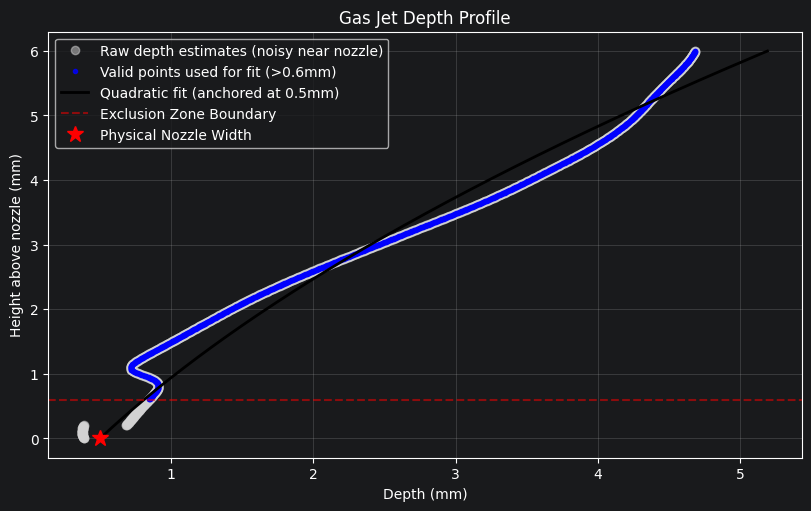

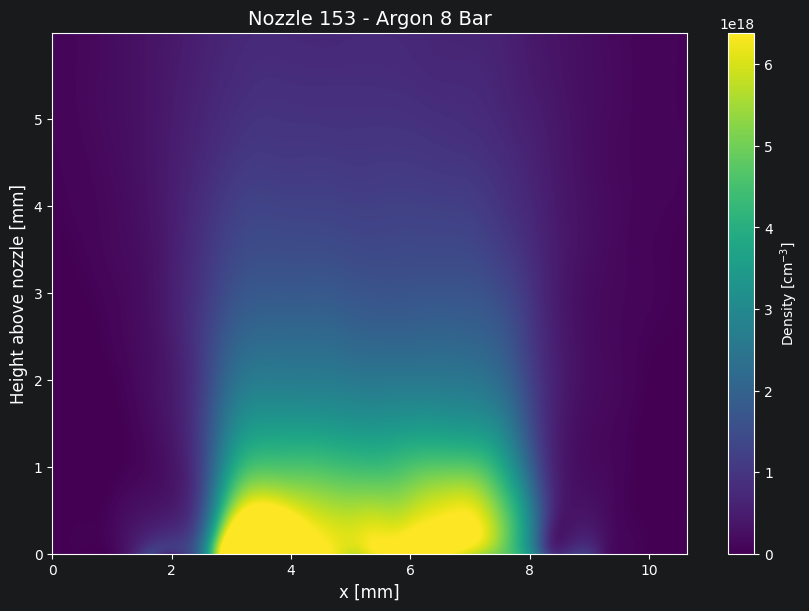

In [34]:
# ==========================================
# 7 BAR ANALYSIS
# ==========================================
# Paths for 7 bar
hdf5_path_90 = r"C:\Users\vmlab\Documents\data\files\2026\09\23\nozzle_155\Ar_7_bar\90_deg"
hdf5_path_0  = r"C:\Users\vmlab\Documents\data\files\2026\09\23\nozzle_155\Ar_7_bar\0_deg"

roi_90 = [2000, 4900, 1100, 3600]
roi_0  = [2000, 4900, 1200, 3400]

# --- 1. Process 90-degree (Perpendicular) ---
ref_img_90, exp_img_90, ref_roi_90, exp_roi_90 = pe.get_interferometry_images(hdf5_path_90, roi=roi_90)
ref_fourier_90 = pe.get_fourier(ref_roi_90)
exp_fourier_90 = pe.get_fourier(exp_roi_90)
dom_freq_90 = pe.get_dominant_frequency(ref_fourier_90, debug=False)
delta_phase_90 = pe.get_delta_phase_wrapped(ref_fourier_90, exp_fourier_90, dom_freq_90, debug=False)
ref_edge_90, *_ = calib.estimate_nozzle_edge(ref_roi_90)
x_left_90, x_right_90 = calib.detect_nozzle_x_range(ref_roi_90, ref_edge_90, debug=False)
calibrated_phase_perp, _ = calib.calibrate_phase(delta_phase_90, ref_edge_90, x_left_90, x_right_90, debug=False)

# --- 2. Process 0-degree (Parallel) ---
ref_img_0, exp_img_0, ref_roi_0, exp_roi_0 = pe.get_interferometry_images(hdf5_path_0, roi=roi_0)
ref_fourier_0 = pe.get_fourier(ref_roi_0)
exp_fourier_0 = pe.get_fourier(exp_roi_0)
dom_freq_0 = pe.get_dominant_frequency(ref_fourier_0, debug=False)
delta_phase_0 = pe.get_delta_phase_wrapped(ref_fourier_0, exp_fourier_0, dom_freq_0, debug=False)
ref_edge_0, *_ = calib.estimate_nozzle_edge(ref_roi_0)
x_left_0, x_right_0 = calib.detect_nozzle_x_range(ref_roi_0, ref_edge_0)
calibrated_phase_para, _ = calib.calibrate_phase(delta_phase_0, ref_edge_0, x_left_0, x_right_0, debug=False)

# --- 3. Crop and Compute Depth (from 0-deg) ---
phi_cropped_para = sa.crop_and_format_phase_map(
    calibrated_phase_para, nozzle_edge_y=ref_edge_0, px_to_mm=px_to_mm, max_height_mm=6.0
)
y_mm_para, depth_fit_para, depth_debug = sa.estimate_depth_profile(
    phi_cropped_para, px_to_mm, nozzle_opening=NOZZLE_OPENING_MM, fit_type="quadratic_constrained", exclude_y_mm=0.6, debug_show=True
)

# --- 4. Crop and Compute Density (from 90-deg) ---
phi_cropped_perp = sa.crop_and_format_phase_map(
    calibrated_phase_perp, nozzle_edge_y=ref_edge_90, px_to_mm=px_to_mm, max_height_mm=6.0
)
density_map, x_mm, y_mm = sa.phase_to_density(
    phi_cropped_perp, px_to_mm, depth_y_mm=y_mm_para, depth_profile_mm=depth_fit_para, gas="argon"
)

# --- 5. Plot Density Map ---
sa.plot_density_map(density_map, x_mm, y_mm, title="Nozzle 153 - Argon 8 Bar")

# 8 Bar Analysis

Unsupported data type for _convert.
Unsupported data type for _convert.


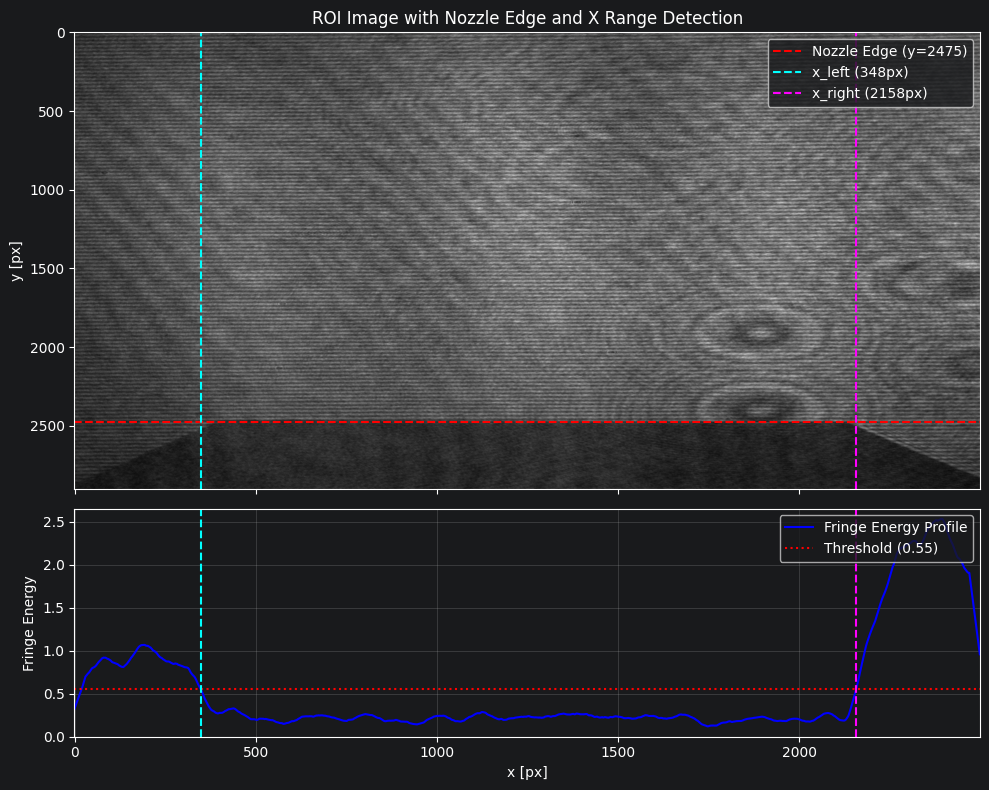

Unsupported data type for _convert.
Unsupported data type for _convert.


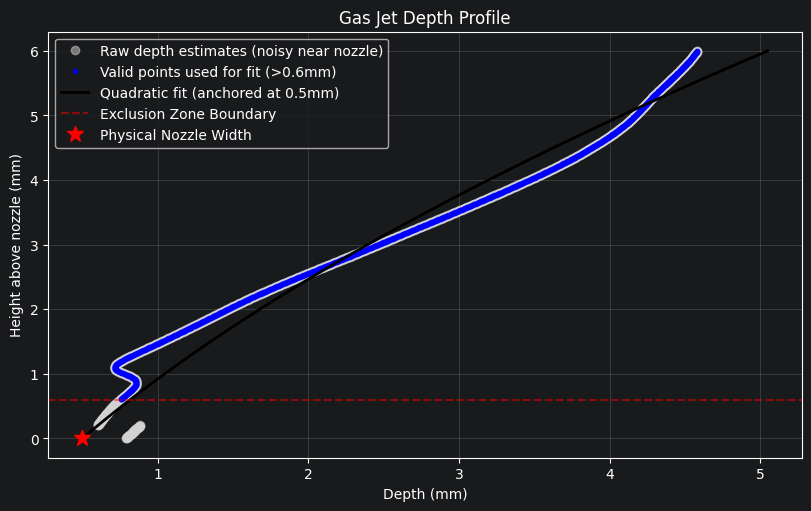

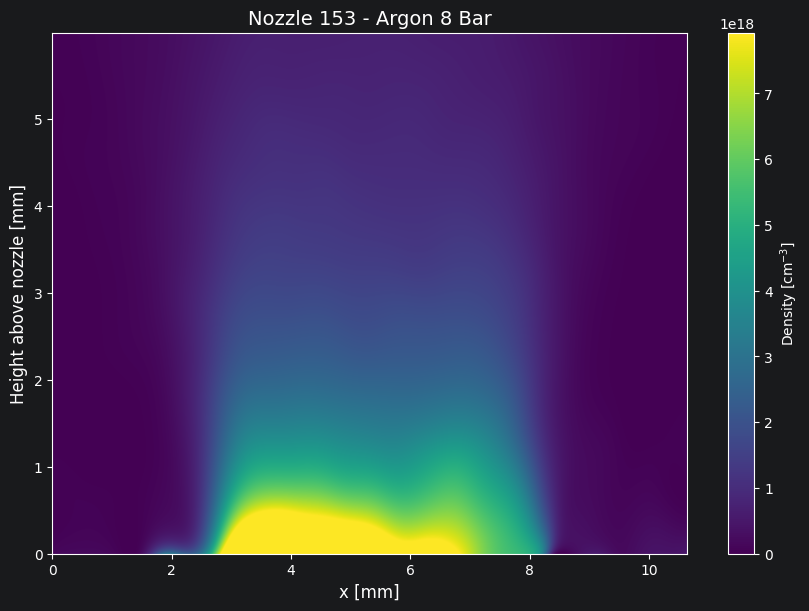

In [37]:
# ==========================================
# 8 BAR ANALYSIS
# ==========================================
# Paths for 8 bar
hdf5_path_90 = r"C:\Users\vmlab\Documents\data\files\2026\09\23\nozzle_155\Ar_8_bar\90_deg"
hdf5_path_0  = r"C:\Users\vmlab\Documents\data\files\2026\09\23\nozzle_155\Ar_8_bar\0_deg"

roi_90 = [2000, 4900, 1100, 3600]
roi_0  = [2000, 4900, 1200, 3400]

# --- 1. Process 90-degree (Perpendicular) ---
ref_img_90, exp_img_90, ref_roi_90, exp_roi_90 = pe.get_interferometry_images(hdf5_path_90, roi=roi_90)
ref_fourier_90 = pe.get_fourier(ref_roi_90)
exp_fourier_90 = pe.get_fourier(exp_roi_90)
dom_freq_90 = pe.get_dominant_frequency(ref_fourier_90, debug=False)
delta_phase_90 = pe.get_delta_phase_wrapped(ref_fourier_90, exp_fourier_90, dom_freq_90, debug=False)
ref_edge_90, *_ = calib.estimate_nozzle_edge(ref_roi_90)
x_left_90, x_right_90 = calib.detect_nozzle_x_range(ref_roi_90, ref_edge_90, debug= False)
calibrated_phase_perp, _ = calib.calibrate_phase(delta_phase_90, ref_edge_90, x_left_90, x_right_90, debug=False)

# --- 2. Process 0-degree (Parallel) ---
ref_img_0, exp_img_0, ref_roi_0, exp_roi_0 = pe.get_interferometry_images(hdf5_path_0, roi=roi_0)
ref_fourier_0 = pe.get_fourier(ref_roi_0)
exp_fourier_0 = pe.get_fourier(exp_roi_0)
dom_freq_0 = pe.get_dominant_frequency(ref_fourier_0, debug=False)
delta_phase_0 = pe.get_delta_phase_wrapped(ref_fourier_0, exp_fourier_0, dom_freq_0, debug=False)
ref_edge_0, *_ = calib.estimate_nozzle_edge(ref_roi_0)
x_left_0, x_right_0 = calib.detect_nozzle_x_range(ref_roi_0, ref_edge_0)
calibrated_phase_para, _ = calib.calibrate_phase(delta_phase_0, ref_edge_0, x_left_0, x_right_0, debug=False)

# --- 3. Crop and Compute Depth (from 0-deg) ---
phi_cropped_para = sa.crop_and_format_phase_map(
    calibrated_phase_para, nozzle_edge_y=ref_edge_0, px_to_mm=px_to_mm, max_height_mm=6.0
)
y_mm_para, depth_fit_para, depth_debug = sa.estimate_depth_profile(
    phi_cropped_para, px_to_mm, nozzle_opening=NOZZLE_OPENING_MM, fit_type="quadratic_constrained", exclude_y_mm=0.6, debug_show=True
)

# --- 4. Crop and Compute Density (from 90-deg) ---
phi_cropped_perp = sa.crop_and_format_phase_map(
    calibrated_phase_perp, nozzle_edge_y=ref_edge_90, px_to_mm=px_to_mm, max_height_mm=6.0
)
density_map, x_mm, y_mm = sa.phase_to_density(
    phi_cropped_perp, px_to_mm, depth_y_mm=y_mm_para, depth_profile_mm=depth_fit_para, gas="argon"
)

# --- 5. Plot Density Map ---
sa.plot_density_map(density_map, x_mm, y_mm, title="Nozzle 153 - Argon 8 Bar")

# 9 Bar Analysis

Unsupported data type for _convert.
Unsupported data type for _convert.
Unsupported data type for _convert.
Unsupported data type for _convert.


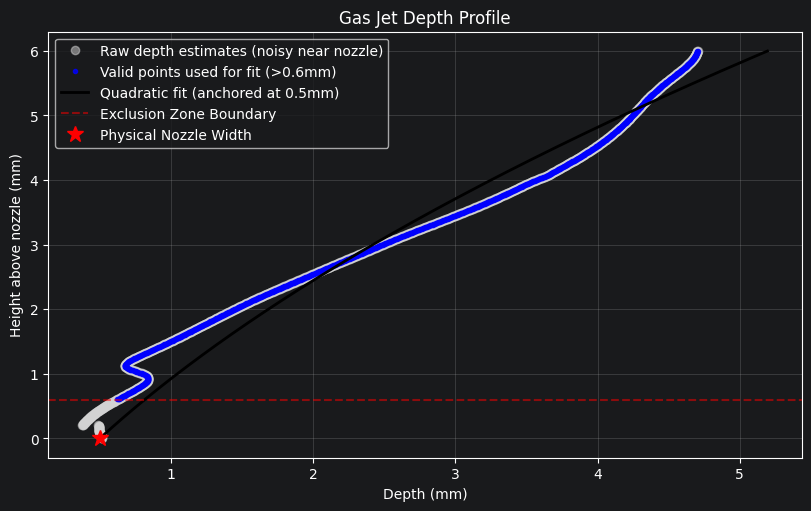

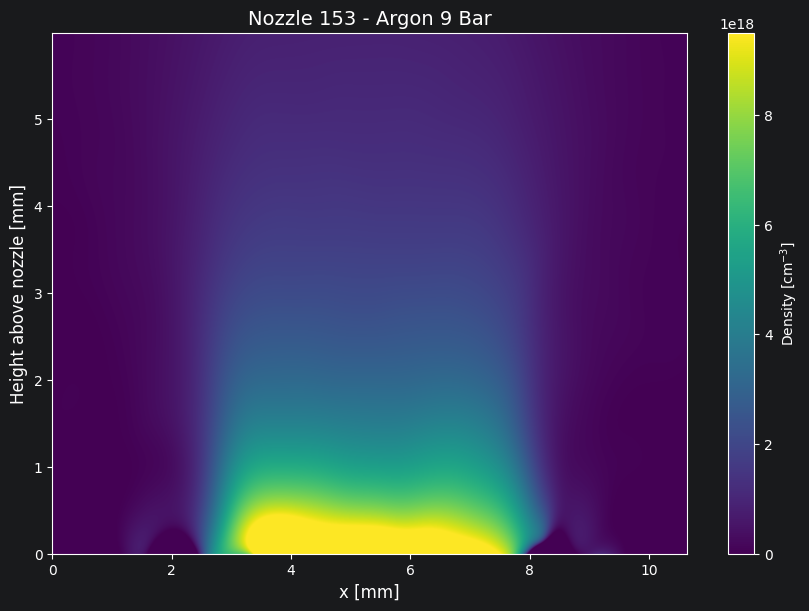

In [38]:
# ==========================================
# 9 BAR ANALYSIS
# ==========================================
# Paths for 9 bar
hdf5_path_90 = r"C:\Users\vmlab\Documents\data\files\2026\09\23\nozzle_155\Ar_9_bar\90_deg"
hdf5_path_0  = r"C:\Users\vmlab\Documents\data\files\2026\09\23\nozzle_155\Ar_9_bar\0_deg"

roi_90 = [2000, 4900, 1100, 3600]
roi_0  = [2000, 4900, 1200, 3400]

# --- 1. Process 90-degree (Perpendicular) ---
ref_img_90, exp_img_90, ref_roi_90, exp_roi_90 = pe.get_interferometry_images(hdf5_path_90, roi=roi_90)
ref_fourier_90 = pe.get_fourier(ref_roi_90)
exp_fourier_90 = pe.get_fourier(exp_roi_90)
dom_freq_90 = pe.get_dominant_frequency(ref_fourier_90, debug=False)
delta_phase_90 = pe.get_delta_phase_wrapped(ref_fourier_90, exp_fourier_90, dom_freq_90, debug=False)
ref_edge_90, *_ = calib.estimate_nozzle_edge(ref_roi_90)
x_left_90, x_right_90 = calib.detect_nozzle_x_range(ref_roi_90, ref_edge_90, debug= False)
calibrated_phase_perp, _ = calib.calibrate_phase(delta_phase_90, ref_edge_90, x_left_90, x_right_90, debug=False)

# --- 2. Process 0-degree (Parallel) ---
ref_img_0, exp_img_0, ref_roi_0, exp_roi_0 = pe.get_interferometry_images(hdf5_path_0, roi=roi_0)
ref_fourier_0 = pe.get_fourier(ref_roi_0)
exp_fourier_0 = pe.get_fourier(exp_roi_0)
dom_freq_0 = pe.get_dominant_frequency(ref_fourier_0, debug=False)
delta_phase_0 = pe.get_delta_phase_wrapped(ref_fourier_0, exp_fourier_0, dom_freq_0, debug=False)
ref_edge_0, *_ = calib.estimate_nozzle_edge(ref_roi_0)
x_left_0, x_right_0 = calib.detect_nozzle_x_range(ref_roi_0, ref_edge_0)
calibrated_phase_para, _ = calib.calibrate_phase(delta_phase_0, ref_edge_0, x_left_0, x_right_0, debug=False)

# --- 3. Crop and Compute Depth (from 0-deg) ---
phi_cropped_para = sa.crop_and_format_phase_map(
    calibrated_phase_para, nozzle_edge_y=ref_edge_0, px_to_mm=px_to_mm, max_height_mm=6.0
)
y_mm_para, depth_fit_para, depth_debug = sa.estimate_depth_profile(
    phi_cropped_para, px_to_mm, nozzle_opening=NOZZLE_OPENING_MM, fit_type="quadratic_constrained", exclude_y_mm=0.6, debug_show=True
)

# --- 4. Crop and Compute Density (from 90-deg) ---
phi_cropped_perp = sa.crop_and_format_phase_map(
    calibrated_phase_perp, nozzle_edge_y=ref_edge_90, px_to_mm=px_to_mm, max_height_mm=6.0
)
density_map, x_mm, y_mm = sa.phase_to_density(
    phi_cropped_perp, px_to_mm, depth_y_mm=y_mm_para, depth_profile_mm=depth_fit_para, gas="argon"
)

# --- 5. Plot Density Map ---
sa.plot_density_map(density_map, x_mm, y_mm, title="Nozzle 153 - Argon 9 Bar")

# 10 Bar Analysis

Unsupported data type for _convert.
Unsupported data type for _convert.
Unsupported data type for _convert.
Unsupported data type for _convert.


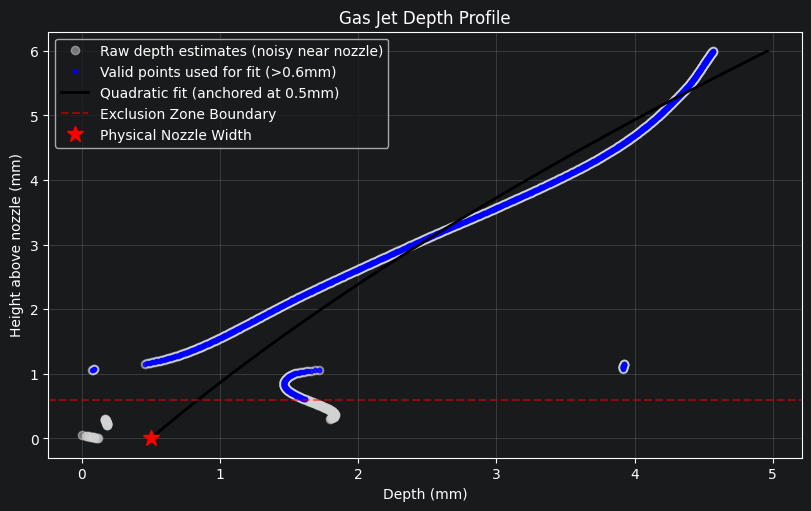

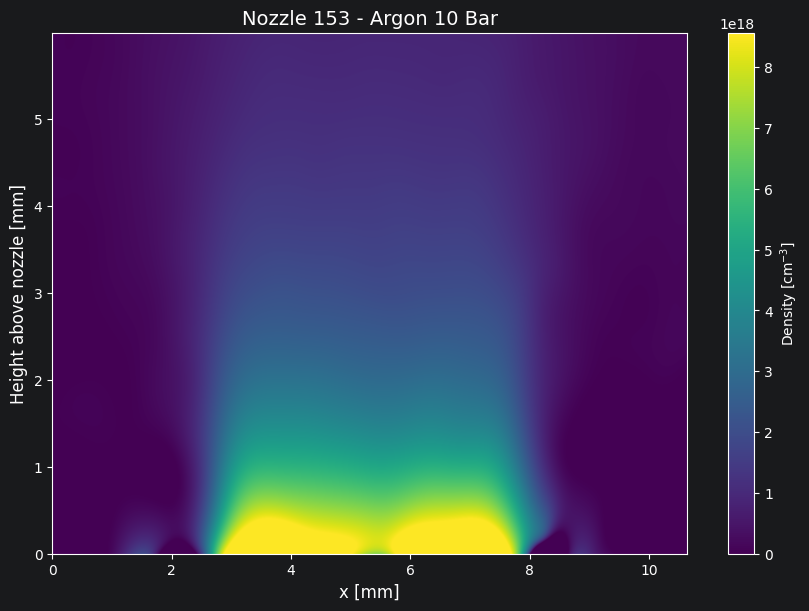

In [39]:
# ==========================================
# 10 BAR ANALYSIS
# ==========================================
# Paths for 10 bar
hdf5_path_90 = r"C:\Users\vmlab\Documents\data\files\2026\09\23\nozzle_155\Ar_10_bar\90_deg"
hdf5_path_0  = r"C:\Users\vmlab\Documents\data\files\2026\09\23\nozzle_155\Ar_10_bar\0_deg"

roi_90 = [2000, 4900, 1100, 3600]
roi_0  = [2000, 4900, 1200, 3400]

# --- 1. Process 90-degree (Perpendicular) ---
ref_img_90, exp_img_90, ref_roi_90, exp_roi_90 = pe.get_interferometry_images(hdf5_path_90, roi=roi_90)
ref_fourier_90 = pe.get_fourier(ref_roi_90)
exp_fourier_90 = pe.get_fourier(exp_roi_90)
dom_freq_90 = pe.get_dominant_frequency(ref_fourier_90, debug=False)
delta_phase_90 = pe.get_delta_phase_wrapped(ref_fourier_90, exp_fourier_90, dom_freq_90, debug=False)
ref_edge_90, *_ = calib.estimate_nozzle_edge(ref_roi_90)
x_left_90, x_right_90 = calib.detect_nozzle_x_range(ref_roi_90, ref_edge_90, debug= False)
calibrated_phase_perp, _ = calib.calibrate_phase(delta_phase_90, ref_edge_90, x_left_90, x_right_90, debug=False)

# --- 2. Process 0-degree (Parallel) ---
ref_img_0, exp_img_0, ref_roi_0, exp_roi_0 = pe.get_interferometry_images(hdf5_path_0, roi=roi_0)
ref_fourier_0 = pe.get_fourier(ref_roi_0)
exp_fourier_0 = pe.get_fourier(exp_roi_0)
dom_freq_0 = pe.get_dominant_frequency(ref_fourier_0, debug=False)
delta_phase_0 = pe.get_delta_phase_wrapped(ref_fourier_0, exp_fourier_0, dom_freq_0, debug=False)
ref_edge_0, *_ = calib.estimate_nozzle_edge(ref_roi_0)
x_left_0, x_right_0 = calib.detect_nozzle_x_range(ref_roi_0, ref_edge_0)
calibrated_phase_para, _ = calib.calibrate_phase(delta_phase_0, ref_edge_0, x_left_0, x_right_0, debug=False)

# --- 3. Crop and Compute Depth (from 0-deg) ---
phi_cropped_para = sa.crop_and_format_phase_map(
    calibrated_phase_para, nozzle_edge_y=ref_edge_0, px_to_mm=px_to_mm, max_height_mm=6.0
)
y_mm_para, depth_fit_para, depth_debug = sa.estimate_depth_profile(
    phi_cropped_para, px_to_mm, nozzle_opening=NOZZLE_OPENING_MM, fit_type="quadratic_constrained", exclude_y_mm=0.6, debug_show=True
)

# --- 4. Crop and Compute Density (from 90-deg) ---
phi_cropped_perp = sa.crop_and_format_phase_map(
    calibrated_phase_perp, nozzle_edge_y=ref_edge_90, px_to_mm=px_to_mm, max_height_mm=6.0
)
density_map, x_mm, y_mm = sa.phase_to_density(
    phi_cropped_perp, px_to_mm, depth_y_mm=y_mm_para, depth_profile_mm=depth_fit_para, gas="argon"
)

# --- 5. Plot Density Map ---
sa.plot_density_map(density_map, x_mm, y_mm, title="Nozzle 153 - Argon 10 Bar")